In [9]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
import tqdm
import matplotlib.pyplot as plt

In [ ]:
folder = r'.\mnist_png\mnist_png\training'
trainSet = datasets.ImageFolder(root=folder, transform=transforms.Compose([transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor()]))

folder = r'.\mnist_png\mnist_png\testing'
testSet = datasets.ImageFolder(root=folder, transform=transforms.Compose([transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor()]))

trainLoader = DataLoader(trainSet, batch_size=64, shuffle=True)
testLoader = DataLoader(testSet, batch_size=64, shuffle=True)


#Creating structures to hold the data

In [ ]:
class cnn(nn.Module):
    def __init__(self, in_channels, num_classes):
 
        super(cnn, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride = 2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)
    

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64*7*7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x) 
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = cnn(in_channels=1, num_classes=10).to(device)

#defining model and other parameters

In [12]:
print(device)

cpu


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

numEpochs = 10

epochList = []
trainAccuracies = []
testAccuracies = []

for epoch in range(numEpochs):
    model.train()
    trainLoss = 0
    correctTrain = 0
    totalTrain = 0

    for data, shouldBes in tqdm.tqdm(trainLoader):   #training loop

        data, shouldBes = data.to(device), shouldBes.to(device)
        Bes = model(data)
        loss = criterion(Bes, shouldBes)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        trainLoss += loss.item()

        _, predicted = torch.max(Bes.data, 1)
        totalTrain += shouldBes.size(0)
        correctTrain += (predicted == shouldBes).sum().item()

    avgTrainAcc = 100 * correctTrain / totalTrain

    model.eval()
    correctTest=0
    totalTest=0
    with torch.no_grad():      #evaluating performane on test set
        for data, labels in testLoader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            totalTest += labels.size(0)
            correctTest += (predicted == labels).sum().item()
            
    avgTestAcc = 100 * correctTest / totalTest

    epochList.append(epoch + 1)
    trainAccuracies.append(avgTrainAcc)
    testAccuracies.append(avgTestAcc)
    print(f'Epoch {epoch+1}: Train Acc: {avgTrainAcc:.2f}% | Test Acc: {avgTestAcc:.2f}%')
    torch.save(model.state_dict(), 'mnist_cnn.pth')

    
print("training done")



100%|██████████| 938/938 [00:56<00:00, 16.65it/s]


Epoch 1: Train Acc: 94.51% | Test Acc: 98.27%


100%|██████████| 938/938 [00:45<00:00, 20.56it/s]


Epoch 2: Train Acc: 98.45% | Test Acc: 98.69%
training done


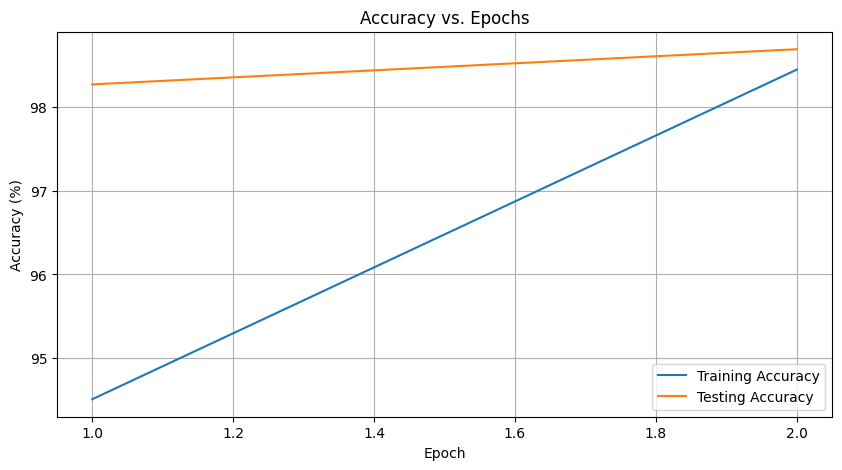

In [ ]:
plt.figure(figsize=(10, 5))   #Plotting graph
plt.plot(epochList, trainAccuracies, label='Training Accuracy')
plt.plot(epochList, testAccuracies, label='Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs. Epochs')
plt.legend()
plt.grid(True)
plt.show()